# Modeling

In [15]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf

## Data exploration

In [2]:
reviews = gpd.read_file("data/pre_2010_brew_reviews.gpkg")

In [3]:
reviews.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,GEOID10,Unnamed: 0,geography,geographic_area_name,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,geometry
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,POINT (-75.15556 39.95551)
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,POINT (-75.15556 39.95551)
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,POINT (-75.15556 39.95551)
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,POINT (-75.15556 39.95551)
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,42101000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,POINT (-75.15556 39.95551)


In [4]:
reviews.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'LISTNAME', 'review_id', 'user_id',
       'useful', 'funny', 'cool', 'text', 'date', 'brewery', 'index_right',
       'GentYN', 'TRACTCE', 'GEOID10', 'Unnamed: 0', 'geography',
       'geographic_area_name', 'tot_pop', 'prop_black', 'prop_asian',
       'prop_hispanic_or_latino', 'prop_white_only', 'geometry'],
      dtype='object')

In [13]:
tract_agg = reviews.groupby("TRACTCE").agg(
    mean_brew_reviews = ("brewery", "mean"),
    prop_black = ("prop_black", "first"),
    prop_asian = ("prop_asian", "first"),
    prop_hispanic_or_latino = ("prop_hispanic_or_latino", "first"),
    gentrified = ("GentYN", "first")
)
tract_agg.head()


,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,gentrified
TRACTCE,,,,,
000100,0.039530,0.063830,0.125359,0.036228,0.0
000200,0.000000,0.102826,1.280899,0.026898,0.0
000300,0.106599,0.107920,0.244241,0.042600,0.0
000401,0.000000,0.186353,0.525176,0.050353,0.0
000402,0.000000,0.056652,0.243794,0.034691,0.0


In [14]:
tract_agg.shape[0]

247

{'whiskers': [<matplotlib.lines.Line2D at 0x1588542d0>,
 'caps': [<matplotlib.lines.Line2D at 0x158854550>,
 'boxes': [<matplotlib.lines.Line2D at 0x158854190>],
 'medians': [<matplotlib.lines.Line2D at 0x1588547d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x158854910>],
 'means': []}

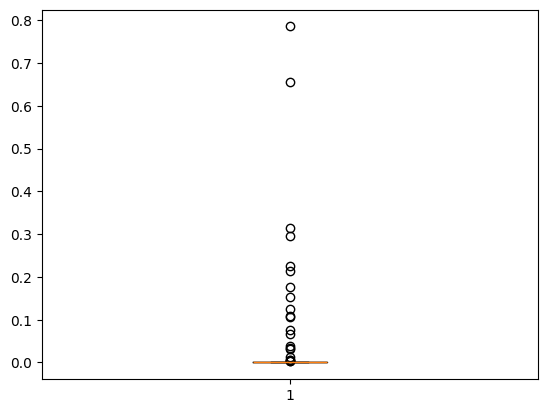

In [11]:
plt.boxplot(tract_agg["mean_brew_reviews"])

In [17]:
mod1 = smf.logit("gentrified ~ mean_brew_reviews + prop_black+prop_asian+prop_hispanic_or_latino",
                 data=tract_agg).fit()

mod1.summary()

Optimization terminated successfully.
         Current function value: 0.371334
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  244
Model:                          Logit   Df Residuals:                      239
Method:                           MLE   Df Model:                            4
Date:                Sat, 23 May 2026   Pseudo R-squ.:                 0.02470
Time:                        13:39:14   Log-Likelihood:                -90.605
converged:                       True   LL-Null:                       -92.900
Covariance Type:            nonrobust   LLR p-value:                    0.3321
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.4872      0.455     -5.468      0.000      -3.379      -1.596
mean_brew_reviews           3.5977      1.886      1.908      0.056      -0.098       7.293
prop_black                  0.4891      0.669      0.731      0.465      -0.822       1.800
prop_asian                  1.2493      0.990      1.262      0.207      -0.691       3.190
prop_hispanic_or_latino     0.9339      1.253      0.746      0.456      -1.521       3.389
===========================================================================================
"""